In [1]:
!pip install torch-geometric rdkit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 42.0 MB/s eta 0:00:00


#Import biblioteka

In [2]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import MoleculeNet
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, global_mean_pool
import matplotlib.pyplot as plt
import numpy as np
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool

#GCN model

## Učitavanje ESOL i podjela

In [3]:
esol_dataset = MoleculeNet(root='data/', name='ESOL').shuffle()

Processing...
Done!


In [4]:
train_size = int(len(esol_dataset) * 0.8)
val_size = int(len(esol_dataset) * 0.1)

In [5]:
train_dataset = esol_dataset[:train_size]
val_dataset = esol_dataset[train_size:train_size + val_size]
test_dataset = esol_dataset[train_size + val_size:]

In [6]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

print(f'Train dataset size: {len(train_dataset)}')
print(f'Validation dataset size: {len(val_dataset)}')
print(f'Test dataset size: {len(test_dataset)}')

Train dataset size: 902
Validation dataset size: 112
Test dataset size: 114


In [7]:
class GCN(torch.nn.Module):
    def __init__(self, num_features, hidden_dim=128, num_tasks=1):
        super().__init__()
        self.conv1 = GCNConv(num_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)

        self.bn1 = torch.nn.BatchNorm1d(hidden_dim)
        self.bn2 = torch.nn.BatchNorm1d(hidden_dim)
        self.bn3 = torch.nn.BatchNorm1d(hidden_dim)

        self.dropout = torch.nn.Dropout(0.2)

        self.lin1 = torch.nn.Linear(hidden_dim, hidden_dim // 2)
        self.lin2 = torch.nn.Linear(hidden_dim // 2, num_tasks)

    def forward(self, data):
        x, edge_index, batch = data.x.float(), data.edge_index, data.batch

        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = self.dropout(x)

        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = self.dropout(x)

        x = F.relu(self.bn3(self.conv3(x, edge_index)))

        x = global_mean_pool(x, batch)

        x = F.relu(self.lin1(x))
        x = self.dropout(x)
        x = self.lin2(x)

        return x

## Trening

In [8]:
def run_training(seed, max_epochs=1000, patience=100, verbose=False):
    torch.manual_seed(seed)
    np.random.seed(seed)

    train_l = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_l = DataLoader(val_dataset, batch_size=32)
    test_l = DataLoader(test_dataset, batch_size=32)

    m = GCN(num_features=esol_dataset.num_features, num_tasks=1)
    opt = torch.optim.Adam(m.parameters(), lr=0.001, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=15, factor=0.5)
    lf = torch.nn.MSELoss()

    best_val = float('inf')
    best_state = None
    no_improve = 0
    train_hist = []
    val_hist = []

    for epoch in range(1, max_epochs + 1):
        m.train()
        tl = 0
        for batch in train_l:
            opt.zero_grad()
            pred = m(batch).squeeze()
            loss = lf(pred, batch.y.squeeze())
            loss.backward()
            opt.step()
            tl += loss.item() * batch.num_graphs
        tl /= len(train_l.dataset)

        m.eval()
        vl = 0
        with torch.no_grad():
            for batch in val_l:
                pred = m(batch).squeeze()
                vl += lf(pred, batch.y.squeeze()).item() * batch.num_graphs
        vl /= len(val_l.dataset)

        sch.step(vl)
        train_hist.append(tl)
        val_hist.append(vl)

        if vl < best_val:
            best_val = vl
            best_state = {k: v.clone() for k, v in m.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if verbose and epoch % 20 == 0:
            print(f"  Epoch {epoch:3d} | Train: {tl:.4f} | Val: {vl:.4f} | Best: {best_val:.4f}")

        if no_improve >= patience:
            break

    m.load_state_dict(best_state)
    m.eval()
    test_loss = 0
    with torch.no_grad():
        for batch in test_l:
            pred = m(batch).squeeze()
            test_loss += lf(pred, batch.y.squeeze()).item() * batch.num_graphs
    test_loss /= len(test_l.dataset)

    return {
        'seed': seed,
        'best_val': best_val,
        'test_mse': test_loss,
        'test_rmse': test_loss ** 0.5,
        'epochs': epoch,
        'model_state': best_state,
        'train_hist': train_hist,
        'val_hist': val_hist,
    }


NUM_RUNS = 50
results = []

for i in range(NUM_RUNS):
    print(f"\n{'='*60}")
    print(f"RUN {i + 1}/{NUM_RUNS} (seed={i})")
    print(f"{'='*60}")
    result = run_training(seed=i, verbose=True)
    results.append(result)
    print(f"\n  Rezultat Run {i+1}: Val MSE={result['best_val']:.4f}, Test RMSE={result['test_rmse']:.4f} (nakon {result['epochs']} epoha)")

print(f"\n\n{'='*60}")
print("SAŽETAK SVIH RUNOVA")
print(f"{'='*60}")
for i, r in enumerate(results):
    print(f"Run {i+1}: Test RMSE = {r['test_rmse']:.4f} log mol/L (val MSE {r['best_val']:.4f})")

best_run = min(results, key=lambda x: x['test_rmse'])
avg_rmse = np.mean([r['test_rmse'] for r in results])
std_rmse = np.std([r['test_rmse'] for r in results])

print(f"\nNajbolji Run: Test RMSE = {best_run['test_rmse']:.4f}")
print(f"Prosjek ± StDev: {avg_rmse:.4f} ± {std_rmse:.4f}")


RUN 1/50 (seed=0)
  Epoch  20 | Train: 1.2098 | Val: 0.7915 | Best: 0.7915
  Epoch  40 | Train: 0.9541 | Val: 0.7203 | Best: 0.6026
  Epoch  60 | Train: 0.9160 | Val: 0.5552 | Best: 0.5237
  Epoch  80 | Train: 0.8118 | Val: 0.4843 | Best: 0.4531
  Epoch 100 | Train: 0.7746 | Val: 0.4357 | Best: 0.4340
  Epoch 120 | Train: 0.6927 | Val: 0.4260 | Best: 0.4094
  Epoch 140 | Train: 0.7201 | Val: 0.3934 | Best: 0.3934
  Epoch 160 | Train: 0.7739 | Val: 0.4417 | Best: 0.3805
  Epoch 180 | Train: 0.6563 | Val: 0.4119 | Best: 0.3805
  Epoch 200 | Train: 0.6471 | Val: 0.4416 | Best: 0.3805
  Epoch 220 | Train: 0.6086 | Val: 0.4339 | Best: 0.3805
  Epoch 240 | Train: 0.6044 | Val: 0.4444 | Best: 0.3805

  Rezultat Run 1: Val MSE=0.3805, Test RMSE=0.7261 (nakon 259 epoha)

RUN 2/50 (seed=1)
  Epoch  20 | Train: 1.0710 | Val: 0.7020 | Best: 0.7020
  Epoch  40 | Train: 0.9398 | Val: 0.6314 | Best: 0.6314
  Epoch  60 | Train: 1.0998 | Val: 0.7144 | Best: 0.5613
  Epoch  80 | Train: 0.7327 | Val: 0.

Spremljen model iz run 2 s Test RMSE = 0.6976


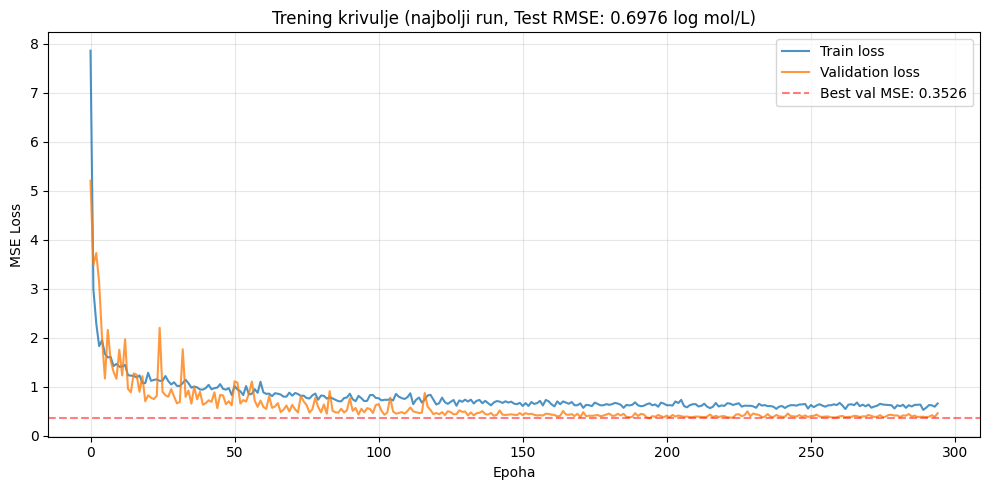

In [9]:
best_run = min(results, key=lambda x: x['test_rmse'])
torch.save(best_run['model_state'], 'gcn_esol.pt')
print(f"Spremljen model iz run {best_run['seed']+1} s Test RMSE = {best_run['test_rmse']:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(best_run['train_hist'], label='Train loss', alpha=0.8)
ax.plot(best_run['val_hist'], label='Validation loss', alpha=0.8)
ax.axhline(best_run['best_val'], color='red', linestyle='--', alpha=0.5, label=f"Best val MSE: {best_run['best_val']:.4f}")
ax.set_xlabel('Epoha')
ax.set_ylabel('MSE Loss')
ax.set_title(f'Trening krivulje (najbolji run, Test RMSE: {best_run["test_rmse"]:.4f} log mol/L)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()